# RivSat: Satellite Remote Sensing of Water Turbidity & TSS
### A Universal, CoastSat-Style, Physics-Based Bio-Optical Processing Framework

**RivSat** provides a complete, research-grade Python framework for **mapping, extracting, and analyzing water turbidity (FNU) and Total Suspended Solids (TSS / SPM in mg/L)** across rivers, estuaries, lakes, and coastal plumes using **Sentinel-2 MSI** and **Landsat 8/9 OLI** via **Google Earth Engine (GEE)**.

```
+----------------------------------------------------------------------------------------+
|                                   RIVSAT PIPELINE                                      |
+----------------------------------------------------------------------------------------+
|  [1. User Configuration] --> [2. Spatial AOI & Layers] --> [3. GEE Cloud Composites]   |
|                                                                     |                  |
|  [6. In-Situ Validation] <-- [5. Profiles & Transects] <-- [4. Radiative Transfer]     |
+----------------------------------------------------------------------------------------+
```

#### Key Features for Universal Use:
1. **Plug-and-Play Configuration**: Set top-level variables in Step 1 (`SITE_NAME`, `START_DATE`, `END_DATE`, `ACQUISITION_MODE`, `SENSORS`) and the entire notebook runs end-to-end dynamically.
2. **Multi-Scale Acquisition Modes**: Support for `"annual"`, `"seasonal"`, `"monthly"`, or `"daily_overpass"` satellite composites.
3. **Dogliotti Blended Radiative Transfer**: Implements the **Dogliotti et al. (2015)** adaptive switching model between Red (665 nm) and NIR (865 nm) bands with smooth weight blending ($0.05 \le \rho_w(665) \le 0.07$).
4. **Multi-Conditional Red-Edge Extension**: Seamlessly switches to Sentinel-2 Band 5 (704 nm) for hyper-turbid river plumes.
5. **CoastSat-Style Spatial Analytics**: Longitudinal along-river chainage profiles, perpendicular cross-sectional channel transects, and virtual station time-series.
6. **Mann-Kendall Trend & Climatology**: Non-parametric trend tests, Sen's slope rates of change, and seasonal sediment flux breakdown.
7. **Dual Spatio-Temporal Matchup & Recalibration**: Validates satellite retrievals against field observations ($R^2$, RMSE, MAPE, Bias) and optionally recalibrates local $A_T$ optical coefficients.

--- 
## Step 1: Centralized User Configuration & Environment Setup

Configure your study site, date range, satellite sensors, and processing parameters below. **All downstream cells will automatically inherit these settings!**

In [15]:
import sys
import os

# Ensure project root is in sys.path
ROOT_DIR = os.path.abspath(".")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Flush cached rivsat modules to guarantee newest code is loaded
for mod in list(sys.modules.keys()):
    if mod.startswith('rivsat'):
        sys.modules.pop(mod, None)

# =============================================================================
# CENTRALIZED USER CONFIGURATION BLOCK (Customize for your study site)
# =============================================================================
SITE_NAME = "Karnaphuli_River_Site"     # Unique study site identifier
START_DATE = "2023-01-01"                # Acquisition start date (YYYY-MM-DD)
END_DATE = "2023-2-20"                  # Acquisition end date (YYYY-MM-DD)
ACQUISITION_MODE = "annual"            # Options: 'annual', 'seasonal', 'monthly', 'daily_overpass'
SENSORS = ["S2", "L8"]                   # Multi-sensor fusion active: Sentinel-2 + Landsat 8/9
MAX_CLOUD_COVER = 30.0                   # Max allowable cloudy pixels %
GEE_PROJECT_ID = None                    # Optional: Google Cloud Project ID (e.g. "my-gee-project")

DATA_DIR = "./data"
OUTPUT_DIR = f"./outputs/{SITE_NAME}"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# =============================================================================

# Import RivSat Core Engine
from rivsat import (
    initialize_gee,
    GEEDownloader,
    SceneProcessor,
    process_batch_parallel,
    TimeSeriesEngine,
    calculate_temporal_trends,
    extract_station_data,
    extract_longitudinal_profile,
    extract_cross_transects,
    find_spatiotemporal_matchups,
    calculate_validation_metrics,
    recalibrate_nechad_coefficient,
    plot_turbidity_map,
    plot_scene_triplet,
    plot_station_timeseries,
    plot_longitudinal_gradient,
    plot_cross_transects,
    plot_validation_scatter,
    load_geojson_polygon,
    load_geojson_features,
    validate_spatial_features,
    create_centerline_draw_map,
    create_stations_draw_map
)

# Initialize Google Earth Engine Python API
initialize_gee(project_id=GEE_PROJECT_ID)
print(f"[OK] Environment initialized for site: {SITE_NAME} | Mode: {ACQUISITION_MODE} | Sensors: {SENSORS}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Google Earth Engine successfully initialized.
[OK] Environment initialized for site: Karnaphuli_River_Site | Mode: annual | Sensors: ['S2', 'L8']


--- 
## Step 2A: Ingest Study Site Area of Interest (AOI Polygon)

Loads your study area bounding polygon from `./data/user_roi.geojson`.

In [16]:
geojson_path = f"{DATA_DIR}/user_roi.geojson"

# Load AOI Polygon Coordinates
aoi_polygon = load_geojson_polygon(geojson_path)
print(f"[OK] Loaded AOI Polygon with {len(aoi_polygon)} coordinate vertices for {SITE_NAME}")

# Compute centroid for map view
mid_lon = float(np.mean([pt[0] for pt in aoi_polygon]))
mid_lat = float(np.mean([pt[1] for pt in aoi_polygon]))

[OK] Loaded AOI Polygon with 16 coordinate vertices for Karnaphuli_River_Site


--- 
## Step 2B: Trace River Centerline (Interactive Polyline Map)

If `./data/centerline.geojson` is missing, trace the river centerline from upstream to downstream using the Polyline tool (in top-left toolbar), then click **Export**.

In [17]:
# Render Centerline Drawing Map (Polyline tool enabled)
centerline_map = create_centerline_draw_map(
    aoi_polygon=aoi_polygon,
    center_coords=(mid_lat, mid_lon),
    zoom_start=13
)
centerline_map

--- 
## Step 2C: Place Virtual Monitoring Stations (Interactive Marker Map)

If `./data/stations.geojson` is missing, place virtual stations along the river channel using the Marker tool (in top-left toolbar), then click **Export**.

In [18]:
# Render Stations Drawing Map (Marker tool enabled)
stations_map = create_stations_draw_map(
    aoi_polygon=aoi_polygon,
    center_coords=(mid_lat, mid_lon),
    zoom_start=13
)
stations_map

--- 
## Step 2D: Ingest & Validate All Spatial Vector Layers

Ingests and verifies spatial layer completeness (AOI Polygon, Virtual Stations, River Centerline).

In [19]:
# Ingest spatial layers from separate or combined GeoJSON files
features = load_geojson_features(
    geojson_path=geojson_path,
    stations_path=f"{DATA_DIR}/stations.geojson",
    centerline_path=f"{DATA_DIR}/centerline.geojson"
)

aoi_polygon = features["aoi_polygon"]
stations = features["stations"]
centerline = features["centerline"]

# Validate spatial layers
validate_spatial_features(features)

print("\n" + "=" * 65)
print(f"  SPATIAL LAYER SUMMARY: {SITE_NAME}")
print("=" * 65)
print(f"  * AOI Bounding Polygon : {len(aoi_polygon) if aoi_polygon else 0} vertices")
print(f"  * Virtual Stations     : {len(stations)} station(s): {[s['name'] for s in stations]}")
print(f"  * River Centerline     : {len(centerline) if centerline else 0} nodes")
print("=" * 65 + "\n")


  SPATIAL LAYER SUMMARY: Karnaphuli_River_Site
  * AOI Bounding Polygon : 16 vertices
  * Virtual Stations     : 4 station(s): ['Station_1', 'Station_2', 'Station_3', 'Station_4']
  * River Centerline     : 12 nodes



--- 
## Step 3: GEE Satellite Acquisition & Multi-Scale Compositing

Queries Google Earth Engine and downloads cloud-free composites based on your selected `ACQUISITION_MODE` (`"annual"`, `"seasonal"`, `"monthly"`, or `"daily_overpass"`).

In [21]:
downloader = GEEDownloader(
    aoi_polygon=geojson_path,
    site_name=SITE_NAME,
    output_dir=DATA_DIR,
    gee_project=GEE_PROJECT_ID
)

# Download imagery with smart disk caching
scene_dirs = downloader.download_imagery(
    start_date=START_DATE,
    end_date=END_DATE,
    mode=ACQUISITION_MODE,
    reducer="median",
    sensors=SENSORS,
    max_cloud_cover=MAX_CLOUD_COVER,
    scale=20.0
)

[OK] Google Earth Engine successfully initialized.

          CLOUD-SIDE TEMPORAL COMPOSITE GENERATOR           
  * Frequency       : ANNUAL
  * Reducer         : MEDIAN (Cloud/Glint Free)
  * Target Periods  : 1 time composite(s)
  * Target Scale    : 20.0 meters



🛰️ GEE Compositing: 100%|████████████████████████| 2/2 [00:29<00:00, 14.57s/composite, current=L8_2023_Annual_Median, sensor=L8]


[OK] Temporal compositing complete. 2 composite scene(s) ready in:
  D:\Softw\bio-optic-river\data\Karnaphuli_River_Site



--- 
## Step 4: High-Throughput Batch Bio-Optical Radiative Transfer Inversion

Executes parallel multi-core processing of Dogliotti blended dual-band models, SBAF cross-sensor harmonization, and Nechad semi-analytical equations.

In [22]:
processed_results = process_batch_parallel(
    scene_dirs,
    max_workers=4,
    apply_sbaf=True,
    use_rededge=True,
    water_mask_strict=False
)

for res in processed_results:
    stats = res['stats']
    print(f"[{stats['sensor']} - {stats['date']}] Mean Turbidity: {stats['turbidity_mean_fnu']:.1f} FNU | Mean TSS: {stats['tss_mean_mg_l']:.1f} mg/L")

[*] Batch processing 2 satellite scenes using 4 parallel workers...


Processing Satellite Scenes:   0%|          | 0/2 [00:00<?, ?it/s]

[OK] Completed processing 2 scenes.
[L8 - 2023_Annual] Mean Turbidity: 1083.6 FNU | Mean TSS: 1166.2 mg/L
[S2 - 2023_Annual] Mean Turbidity: 693.1 FNU | Mean TSS: 747.2 mg/L


--- 
## Step 5: Multi-Panel & Mode-Aware Bio-Optical Product Visualizer

Inspect the 3-panel scientific comparison figure (**True Color RGB**, **Calibrated Turbidity FNU**, **Total Suspended Solids mg/L**) and multi-scene comparison grids tailored to your selected `ACQUISITION_MODE` (`annual`, `seasonal`, `monthly`, `daily_overpass`).

[OK] 2 scene composite(s) available for mode: 'annual'

[OK] Saved comparison triplet figure: ./outputs/Karnaphuli_River_Site/scene_triplet_plot.png


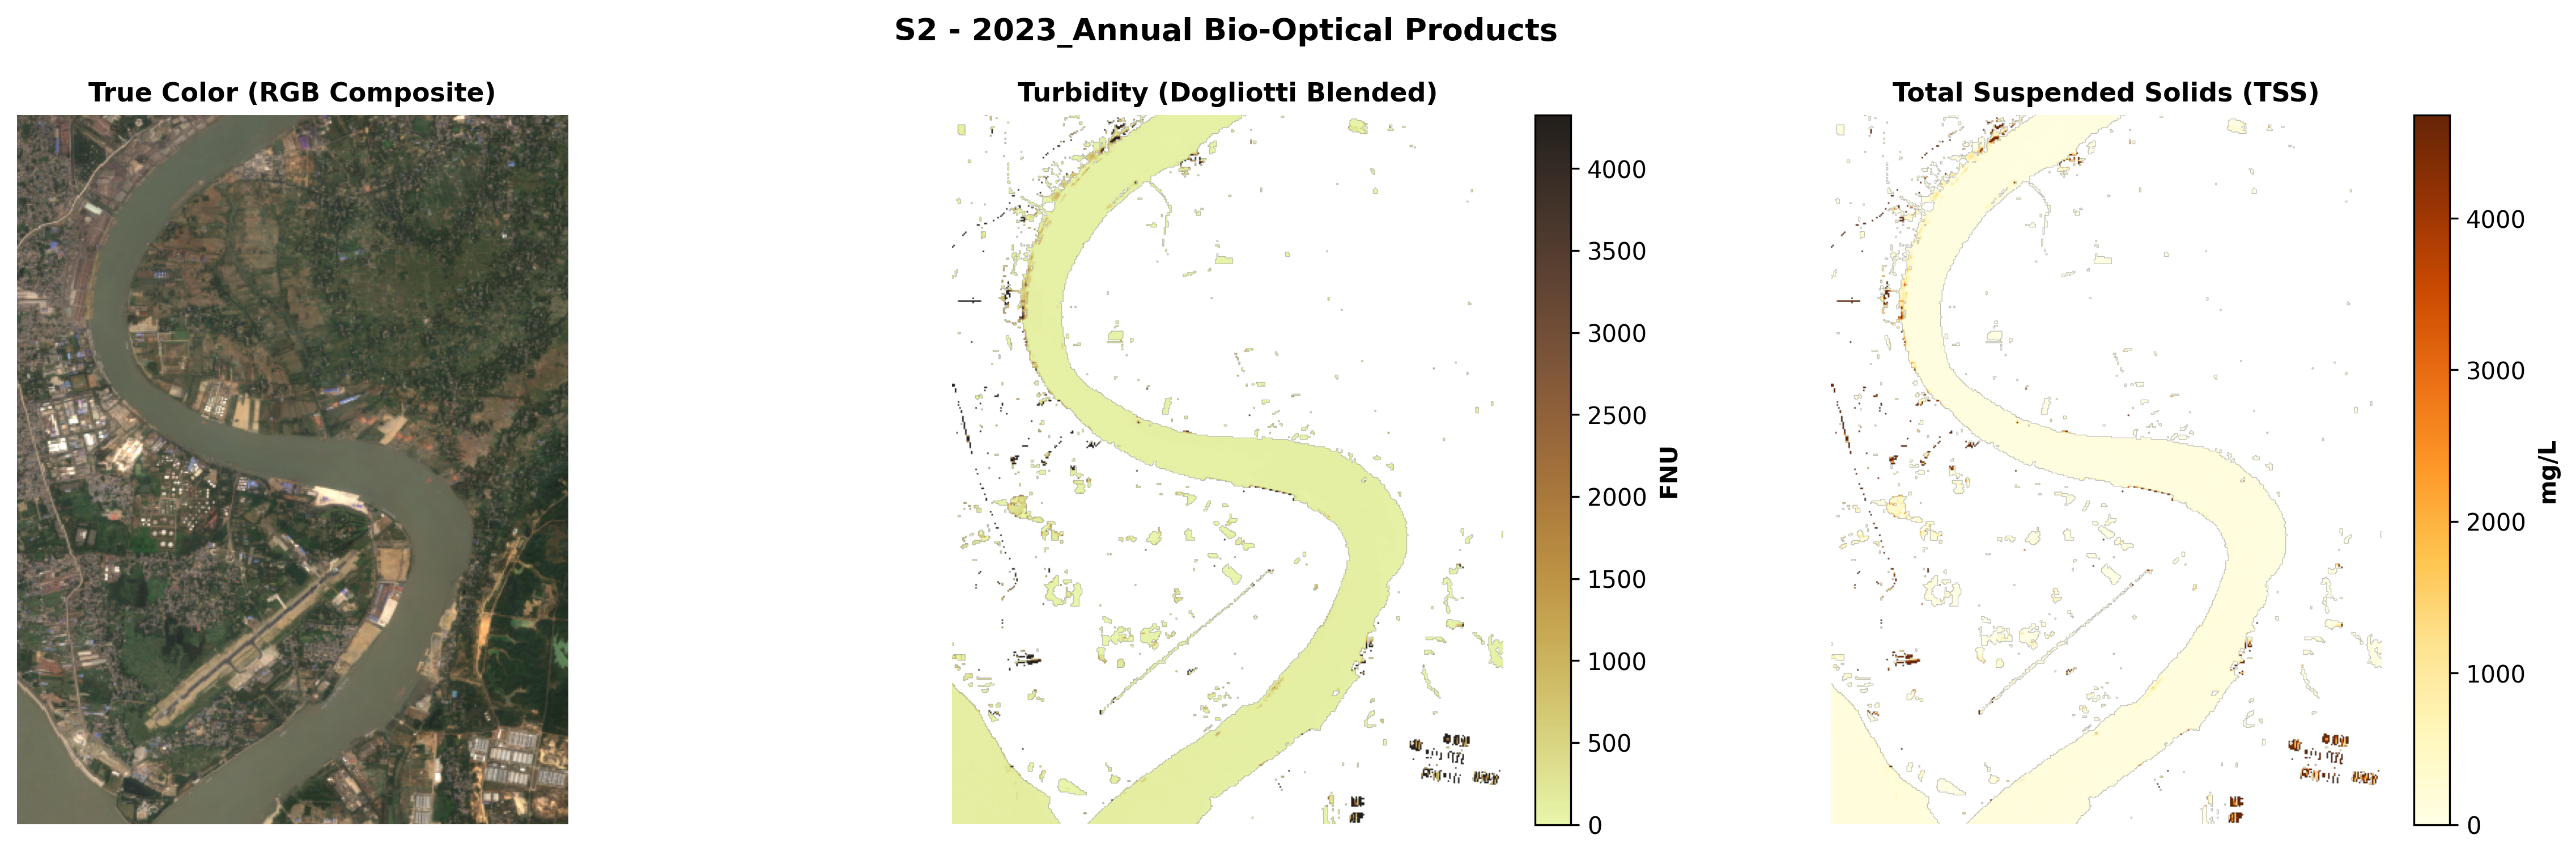


[INFO] Annual Median Composite active: Single representative annual baseline figure rendered above.


In [23]:
if 'processed_results' in locals() and len(processed_results) > 0:
    print(f"[OK] {len(processed_results)} scene composite(s) available for mode: '{ACQUISITION_MODE}'\n")
    
    # 1. Primary 3-Panel Scientific Product Triplet (Latest Composite)
    latest = processed_results[-1]
    r = np.nan_to_num(latest['rho_red'], nan=0.0)
    g = np.nan_to_num(latest['rho_green'], nan=0.0)
    b = np.nan_to_num(latest['rho_blue'], nan=0.0)
    rgb = np.clip(np.dstack([r, g, b]) * 3.5, 0.0, 1.0)

    fig_triplet = plot_scene_triplet(
        rgb_composite=rgb,
        turbidity_arr=latest['turbidity'],
        tss_arr=latest['tss'],
        scene_title=f"{latest['stats']['sensor']} - {latest['stats']['date']} Bio-Optical Products",
        save_path=f"{OUTPUT_DIR}/scene_triplet_plot.png"
    )
    plt.show()

    # 2. Mode-Aware Multi-Scene Overview Grid Visualizer with Dynamic 98th Percentile Color Scaling
    if ACQUISITION_MODE == "seasonal" and len(processed_results) >= 4:
        print("\n[INFO] Rendering 2x2 Seasonal Turbidity Grid...")
        fig_seas, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes_flat = axes.flatten()
        for idx, res in enumerate(processed_results[:4]):
            turb_arr = res["turbidity"]
            valid_vals = turb_arr[~np.isnan(turb_arr) & (turb_arr > 0)]
            vmax_dynamic = float(np.percentile(valid_vals, 98)) if len(valid_vals) > 0 else 200.0
            vmax_dynamic = max(vmax_dynamic, 30.0)
            
            im = axes_flat[idx].imshow(turb_arr, cmap="turbo", vmin=0, vmax=vmax_dynamic)
            axes_flat[idx].set_title(f"{res['stats']['date']} Composite (Max: {vmax_dynamic:.0f} FNU)", fontsize=11, fontweight="bold")
            axes_flat[idx].axis("off")
            plt.colorbar(im, ax=axes_flat[idx], shrink=0.75, label="Turbidity (FNU)")
        plt.suptitle(f"Seasonal Water Turbidity Dynamics: {SITE_NAME}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/seasonal_turbidity_grid.png", dpi=300, bbox_inches="tight")
        plt.show()

    elif ACQUISITION_MODE == "monthly" and len(processed_results) >= 3:
        print(f"\n[INFO] Rendering Multi-Month Turbidity Grid ({len(processed_results)} months)...")
        n_scenes = len(processed_results)
        cols = 4
        rows = int(np.ceil(n_scenes / cols))
        fig_month, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        axes_flat = np.atleast_1d(axes).flatten()
        for idx, res in enumerate(processed_results):
            turb_arr = res["turbidity"]
            valid_vals = turb_arr[~np.isnan(turb_arr) & (turb_arr > 0)]
            vmax_dynamic = float(np.percentile(valid_vals, 98)) if len(valid_vals) > 0 else 200.0
            im = axes_flat[idx].imshow(turb_arr, cmap="turbo", vmin=0, vmax=vmax_dynamic)
            axes_flat[idx].set_title(f"{res['stats']['date']}", fontsize=10, fontweight="bold")
            axes_flat[idx].axis("off")
        for idx in range(n_scenes, len(axes_flat)):
            axes_flat[idx].axis("off")
        plt.suptitle(f"Monthly Water Turbidity Maps: {SITE_NAME}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/monthly_turbidity_grid.png", dpi=300, bbox_inches="tight")
        plt.show()

    elif ACQUISITION_MODE == "annual":
        print(f"\n[INFO] Annual Median Composite active: Single representative annual baseline figure rendered above.")

    elif ACQUISITION_MODE == "daily_overpass" and len(processed_results) > 1:
        print(f"\n[INFO] Daily Overpass Mode: Processed {len(processed_results)} raw overpasses. Inspecting latest overpass above.")

else:
    print("[!] No processed scenes found. Please run Step 4 first.")

--- 
## Step 6: Virtual Stations Time-Series & Mann-Kendall Trend Analysis

Extract multi-temporal water quality dynamics across virtual monitoring stations and compute **Mann-Kendall non-parametric trend statistics** and **Sen's slope rates of change**.

[OK] Exported time-series to ./outputs/Karnaphuli_River_Site/turbidity_timeseries.csv
[OK] Saved time-series plot: ./outputs/Karnaphuli_River_Site/timeseries_plot.png


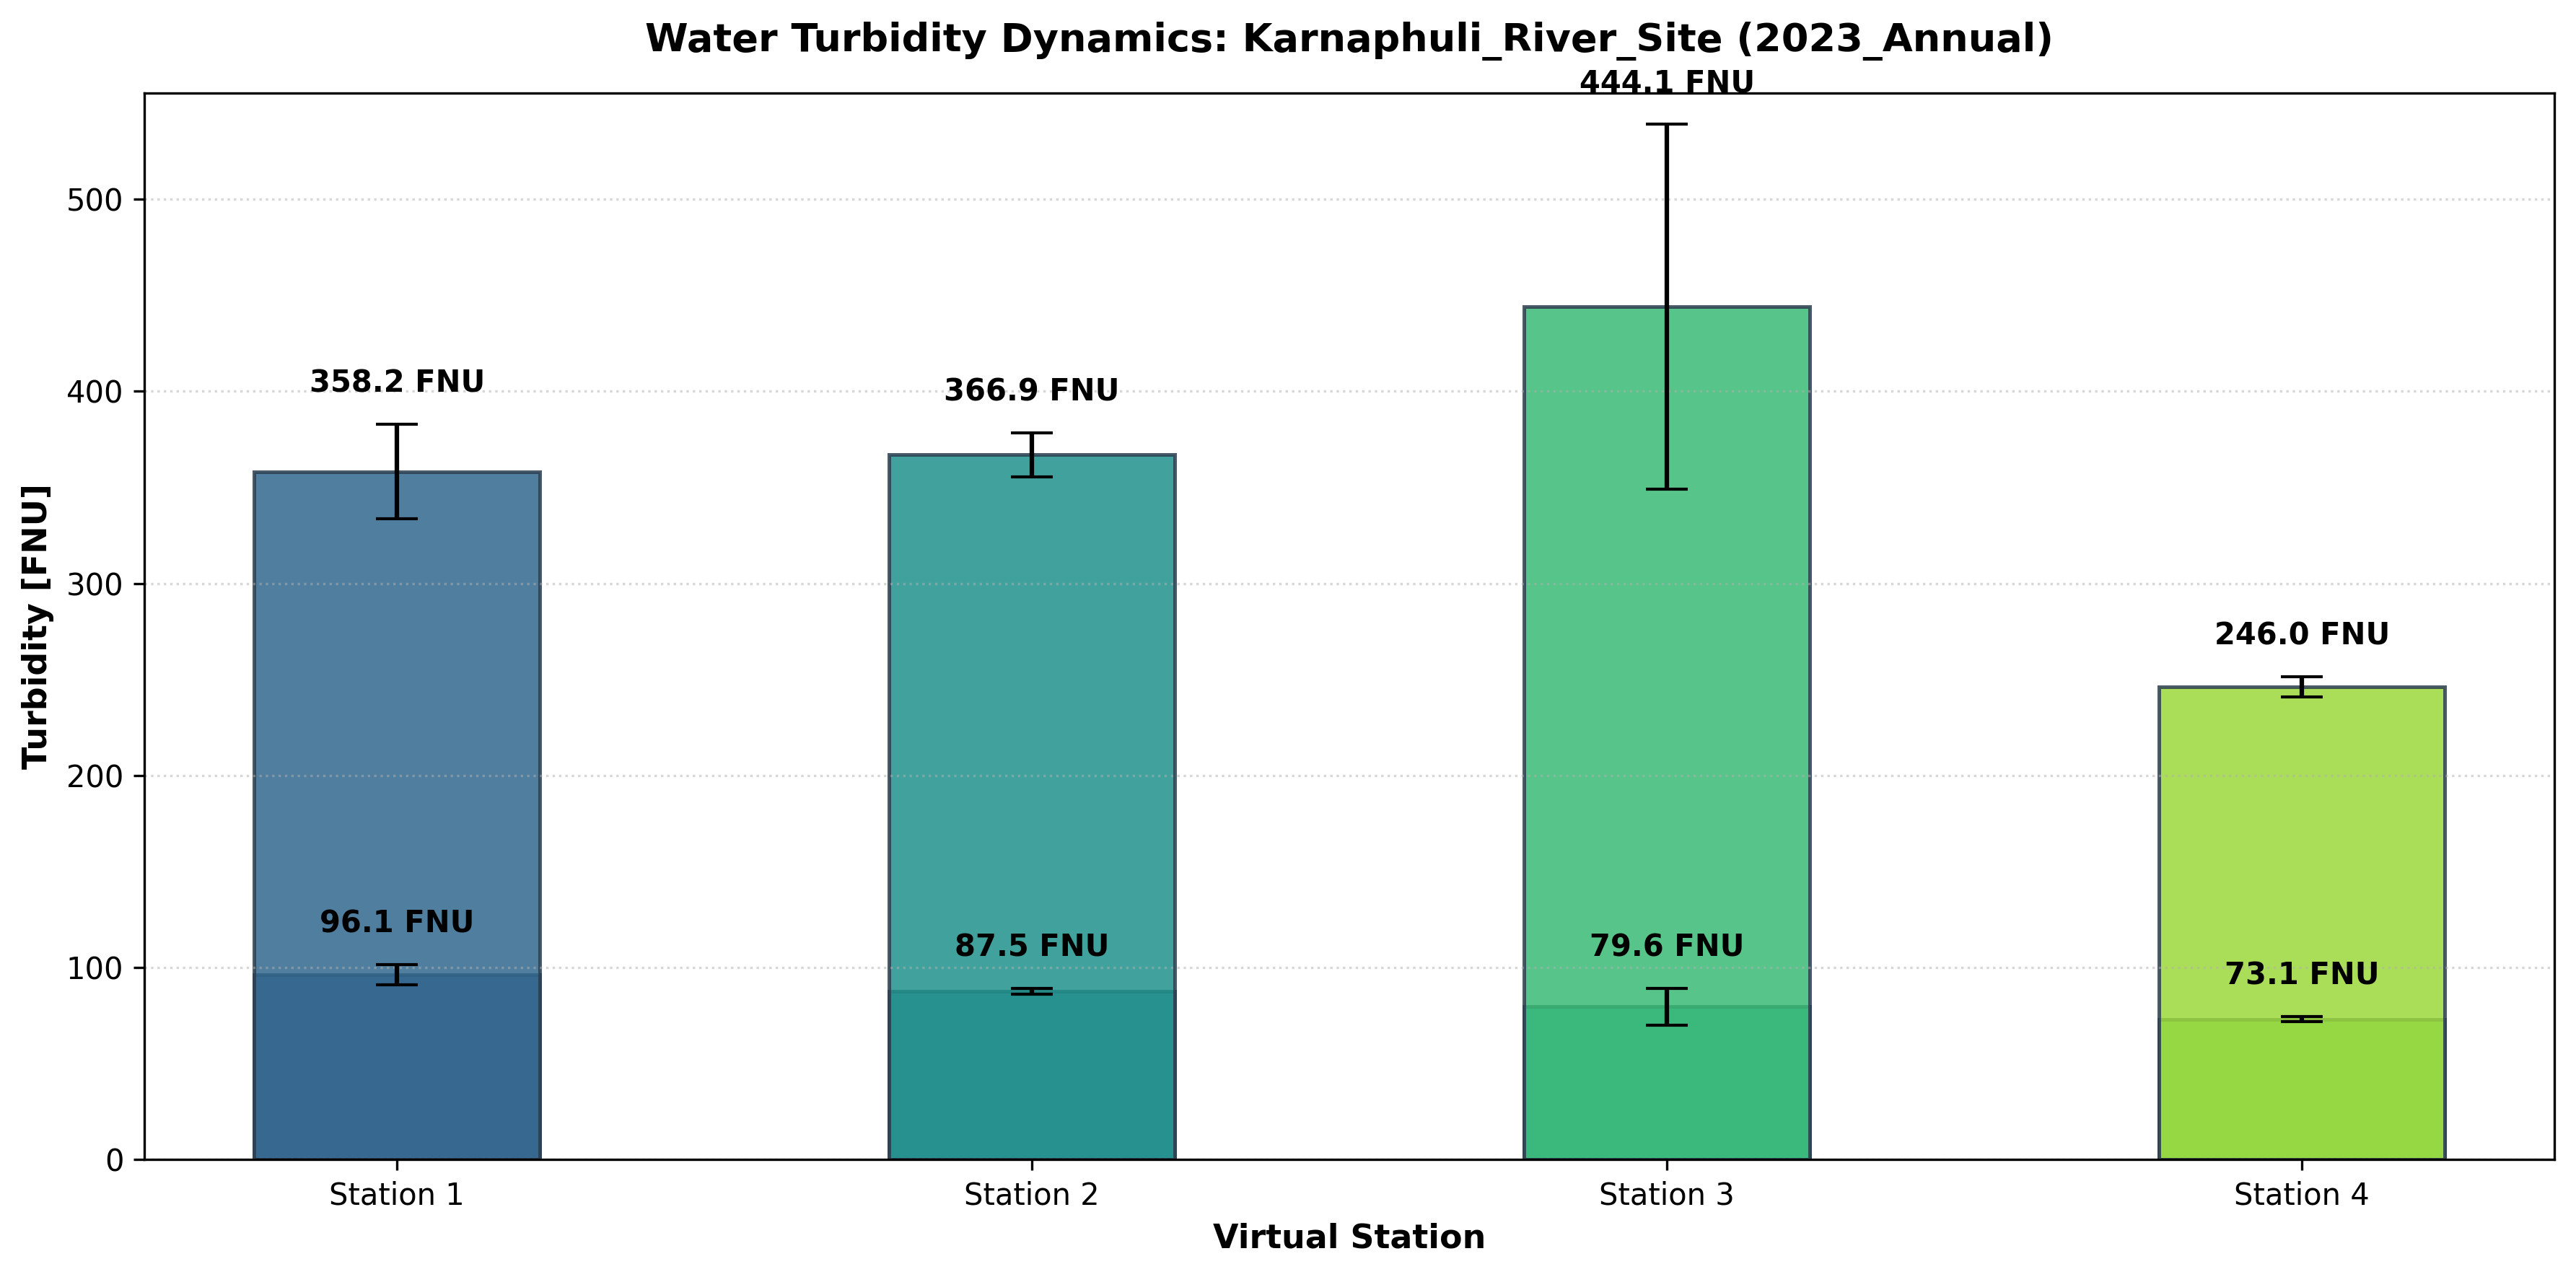


          MANN-KENDALL TREND & RATE OF CHANGE SUMMARY           
station_name  N_observations   mean_val  mann_kendall_z  p_value  sens_slope_annual           trend_direction
   Station_1               2 227.137264             0.0      1.0                0.0 Insufficient Data (N < 3)
   Station_2               2 227.217583             0.0      1.0                0.0 Insufficient Data (N < 3)
   Station_3               2 261.854275             0.0      1.0                0.0 Insufficient Data (N < 3)
   Station_4               2 159.540882             0.0      1.0                0.0 Insufficient Data (N < 3)


In [24]:
if stations and len(stations) > 0:
    ts_engine = TimeSeriesEngine(scene_dirs)
    ts_df = ts_engine.extract_station_timeseries(stations, parameter="turbidity")

    # Export time-series data to CSV
    csv_out = f"{OUTPUT_DIR}/turbidity_timeseries.csv"
    ts_df.to_csv(csv_out, index=False)
    print(f"[OK] Exported time-series to {csv_out}")

    # Interpolate temporal gaps for smooth continuous trend plotting
    clean_ts_df = TimeSeriesEngine.interpolate_gaps(ts_df, parameter="turbidity", method="linear")

    # Plot Multi-Station Adaptive Chart (Bar Chart for single date, Ribbon Line Chart for multi-date)
    fig_ts = plot_station_timeseries(
        clean_ts_df,
        parameter="turbidity",
        unit="FNU",
        title=f"Water Turbidity Dynamics: {SITE_NAME}",
        save_path=f"{OUTPUT_DIR}/timeseries_plot.png"
    )
    plt.show()

    # Calculate Mann-Kendall Trend & Rate of Change Statistics
    trend_results = calculate_temporal_trends(ts_df, parameter="turbidity")
    print("\n" + "=" * 65)
    print("          MANN-KENDALL TREND & RATE OF CHANGE SUMMARY           ")
    print("=" * 65)
    print(trend_results["trends"][["station_name", "N_observations", "mean_val", "mann_kendall_z", "p_value", "sens_slope_annual", "trend_direction"]].to_string(index=False))
    print("=" * 65)
else:
    print("[i] No Virtual Stations defined. Skipping Step 6.")

--- 
## Step 7: Along-River Longitudinal Profile & Cross-Sectional Transects

Extract CoastSat-style **along-river longitudinal gradient** (Chainage km vs. Turbidity) and **perpendicular cross-sectional transects** (lateral plume diffusion across the channel).

[OK] Saved longitudinal gradient plot: ./outputs/Karnaphuli_River_Site/longitudinal_gradient.png


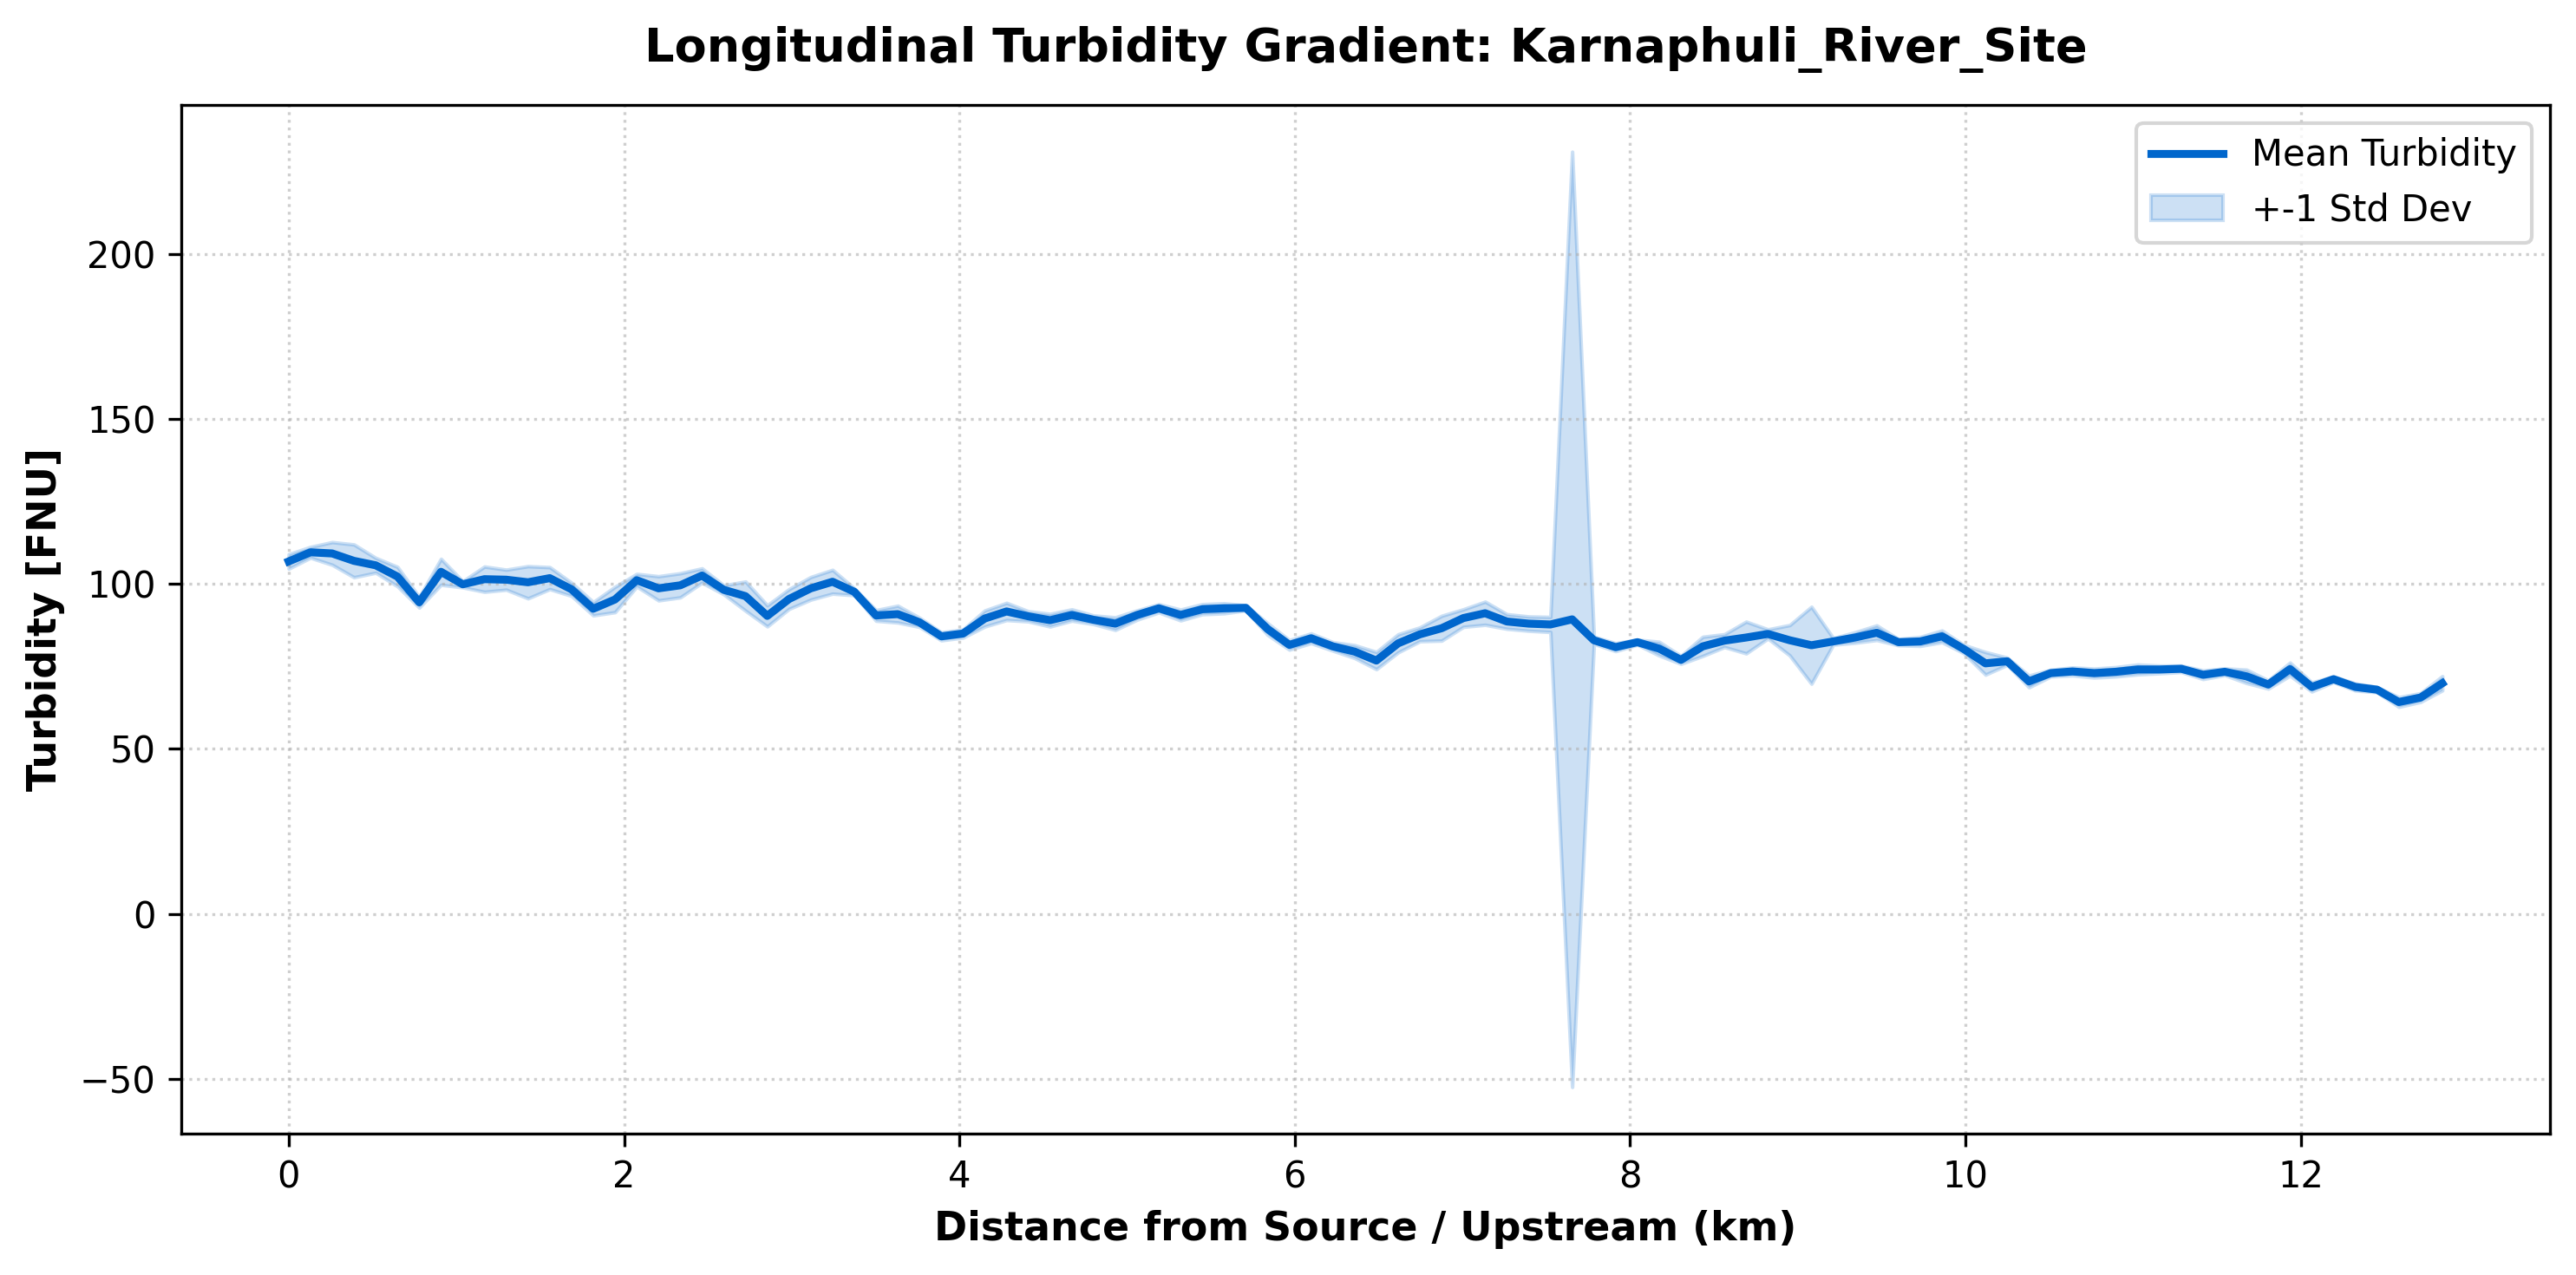

[OK] Saved cross-transect plot: ./outputs/Karnaphuli_River_Site/cross_transects.png


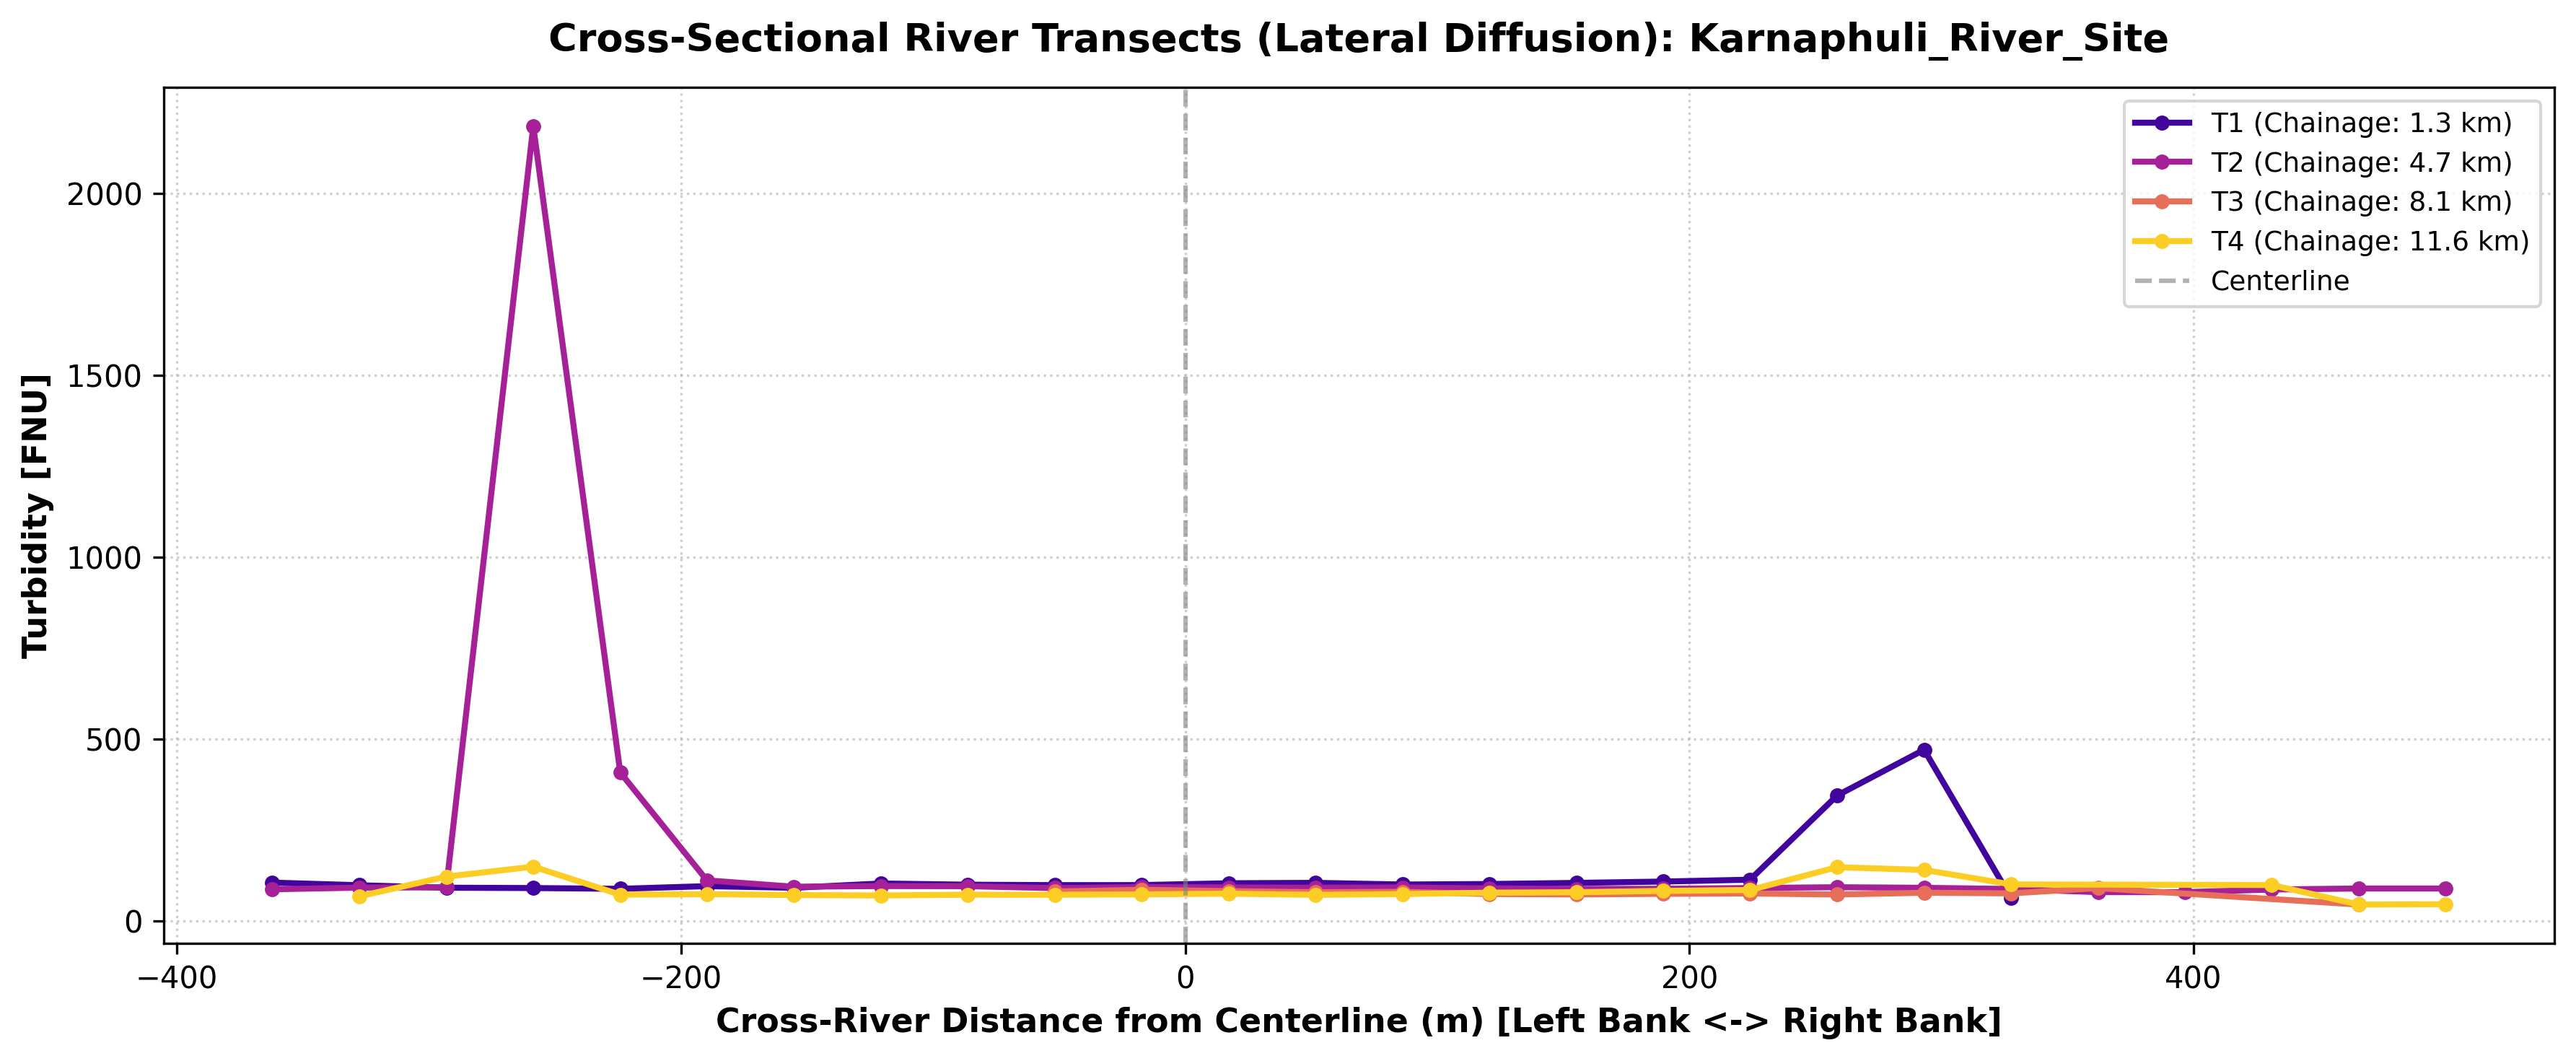

In [25]:
if 'processed_results' in locals() and len(processed_results) > 0 and centerline:
    latest = processed_results[-1]
    
    # 1. Longitudinal Centerline Gradient (Chainage vs Turbidity)
    profile_df = extract_longitudinal_profile(
        raster_data=latest["turbidity"],
        transform=latest["profile"]["transform"],
        centerline_coords=centerline,
        num_samples=100
    )
    fig_grad = plot_longitudinal_gradient(
        profile_df,
        param_name="Turbidity",
        unit="FNU",
        title=f"Longitudinal Turbidity Gradient: {SITE_NAME}",
        save_path=f"{OUTPUT_DIR}/longitudinal_gradient.png"
    )
    plt.show()

    # 2. CoastSat-Style Cross-Sectional Transects (Channel Width Dynamics)
    cross_df = extract_cross_transects(
        raster_data=latest["turbidity"],
        transform=latest["profile"]["transform"],
        centerline_coords=centerline,
        num_transects=4,
        transect_length_m=1000.0,  # 1000m total sampling width (±500m across channel)
        samples_per_transect=30
    )
    fig_cross = plot_cross_transects(
        cross_df,
        param_name="Turbidity",
        unit="FNU",
        title=f"Cross-Sectional River Transects (Lateral Diffusion): {SITE_NAME}",
        save_path=f"{OUTPUT_DIR}/cross_transects.png"
    )
    plt.show()